# 📊 Анализ данных о дефектах в программном обеспечении

## Исследование метрик кода и их связи с дефектами

Этот ноутбук анализирует данные, подготовленные ETL-конвейером, чтобы понять, какие характеристики кода влияют на появление ошибок.

In [1]:
# 1. Загружаем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Настройки графиков
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

# Настройки pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("✅ Библиотеки загружены")

C:\Users\Kuzmi\AppData\Local\Temp\ipykernel_9632\3202651783.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


✅ Библиотеки загружены


In [2]:
# 2. Загружаем данные
data_path = Path("../data/final/final_defect_data.csv")

if not data_path.exists():
    # Если нет финальных, пробуем очищенные
    data_path = Path("../data/processed/clean_defect_data.csv")

df = pd.read_csv(data_path)
print(f"✅ Данные загружены: {data_path.name}")
print(f"📊 Размер: {df.shape[0]} строк, {df.shape[1]} колонок")

✅ Данные загружены: final_defect_data.csv
📊 Размер: 1000 строк, 11 колонок


In [3]:
# 3. Первый взгляд на данные
print("📋 Первые 5 строк:")
df.head()

📋 Первые 5 строк:


,loc,cyclo,length,volume,difficulty,int_fan_in,int_fan_out,num_operators,num_operands,branch_count,defect_label
0,0.779,0.478,0.274,0.545,0.564,0.222,0.444,0.736,0.807,0.643,0
1,0.595,0.609,0.743,0.759,0.451,0.222,0.000,0.577,0.201,0.143,0
2,0.896,0.000,0.968,0.754,0.673,1.000,0.000,0.117,0.020,0.000,1
3,0.782,0.565,0.165,0.018,0.584,0.000,1.000,0.616,0.482,0.500,0
4,0.758,0.217,0.561,0.126,0.526,0.556,0.222,0.656,0.656,0.857,1


In [4]:
# 4. Информация о данных
print("📊 Информация о данных:")
df.info()

📊 Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   loc            1000 non-null   float64
 1   cyclo          1000 non-null   float64
 2   length         1000 non-null   float64
 3   volume         1000 non-null   float64
 4   difficulty     1000 non-null   float64
 5   int_fan_in     1000 non-null   float64
 6   int_fan_out    1000 non-null   float64
 7   num_operators  1000 non-null   float64
 8   num_operands   1000 non-null   float64
 9   branch_count   1000 non-null   float64
 10  defect_label   1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [5]:
# 5. Статистика числовых колонок
print("📈 Статистика числовых колонок:")
df.describe()

📈 Статистика числовых колонок:


,loc,cyclo,length,volume,difficulty,int_fan_in,int_fan_out,num_operators,num_operands,branch_count,defect_label
count,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000,1000.000
mean,0.521,0.493,0.510,0.506,0.502,0.504,0.511,0.494,0.513,0.515,0.326
std,0.289,0.301,0.290,0.291,0.285,0.316,0.321,0.295,0.277,0.314,0.469
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.279,0.217,0.255,0.253,0.263,0.222,0.222,0.231,0.281,0.214,0.000
50%,0.532,0.478,0.514,0.523,0.511,0.556,0.556,0.495,0.517,0.571,0.000
75%,0.767,0.739,0.762,0.759,0.751,0.778,0.778,0.757,0.743,0.786,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [6]:
# 6. Проверка пропущенных значений
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Пропущено': missing,
    'Процент': missing_pct
})

print("🔍 Пропущенные значения:")
missing_df[missing_df['Пропущено'] > 0]

🔍 Пропущенные значения:


,Пропущено,Процент


## 🎯 1. Анализ целевой переменной (дефекты)

In [7]:
# Находим колонку с метками дефектов
target_col = None
for col in ['defect_label', 'defect', 'bugs', 'has_defect']:
    if col in df.columns:
        target_col = col
        break

if target_col:
    print(f"✅ Найдена целевая колонка: {target_col}")
else:
    print("❌ Целевая колонка не найдена")
    target_col = df.columns[0]  # берем первую колонку для демо

✅ Найдена целевая колонка: defect_label


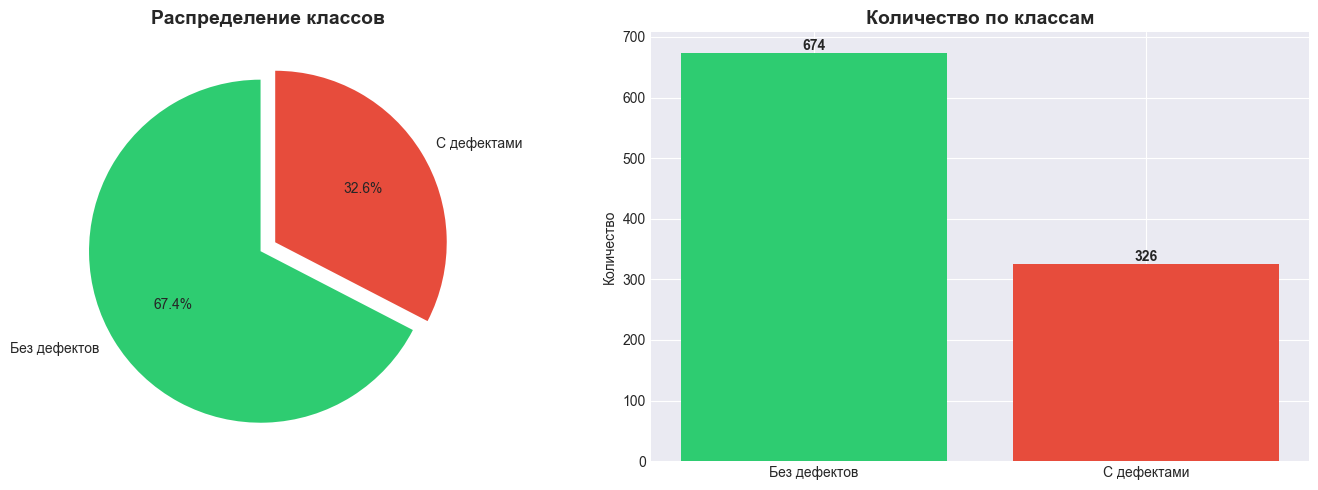


📊 Статистика классов:
  Без дефектов: 674 (67.4%)
  С дефектами: 326 (32.6%)


In [11]:
# Считаем распределение
class_counts = df[target_col].value_counts().sort_index()

# График
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Круговая диаграмма
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(class_counts.values, 
            labels=['Без дефектов', 'С дефектами'],
            autopct='%1.1f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title('Распределение классов', fontsize=14, fontweight='bold')

# Столбчатая диаграмма
bars = axes[1].bar(['Без дефектов', 'С дефектами'], class_counts.values, color=colors)
axes[1].set_title('Количество по классам', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Количество')

# Добавляем цифры на столбцы
for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Статистика
print("\n📊 Статистика классов:")
for i, count in class_counts.items():
    pct = (count / len(df)) * 100
    status = "С дефектами" if i == 1 else "Без дефектов"
    print(f"  {status}: {count} ({pct:.1f}%)")

# Проверка на дисбаланс
if len(class_counts) == 2:
    minority_pct = min(class_counts.values) / len(df) * 100
    if minority_pct < 20:
        print(f"\n⚠️  Дисбаланс классов! Доля минорного класса: {minority_pct:.1f}%")

## 📈 2. Анализ метрик кода

In [12]:
# Определяем метрики кода (числовые колонки кроме целевой)
numeric_cols = df.select_dtypes(include=[np.number]).columns
feature_cols = [col for col in numeric_cols if col != target_col]

print(f"Найдено метрик: {len(feature_cols)}")
print(f"Метрики: {', '.join(feature_cols[:10])}")
if len(feature_cols) > 10:
    print(f"... и еще {len(feature_cols) - 10}")

Найдено метрик: 10
Метрики: loc, cyclo, length, volume, difficulty, int_fan_in, int_fan_out, num_operators, num_operands, branch_count


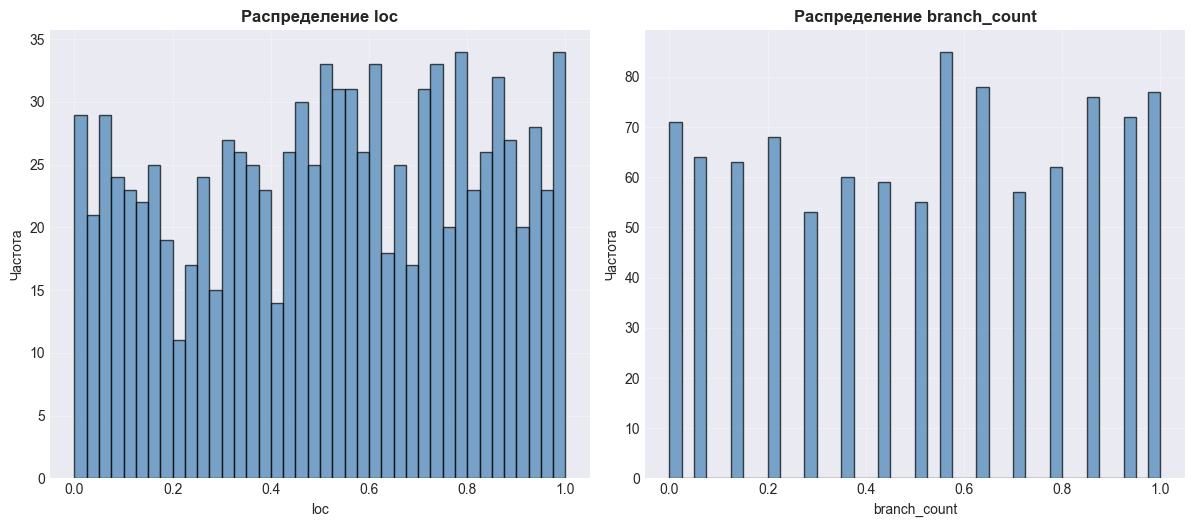

In [13]:
# Выбираем топ-6 метрик для визуализации
important_metrics = ['loc', 'cyclo_complexity', 'halstead_volume', 
                    'branch_count', 'condition_count', 'halstead_difficulty']

available_metrics = [m for m in important_metrics if m in df.columns]

if available_metrics:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(available_metrics):
        # Логарифмическая шкала для больших значений
        data = df[metric]
        if data.max() > 1000:
            data = np.log1p(data)
            xlabel = f'log({metric}+1)'
        else:
            xlabel = metric
        
        axes[i].hist(data, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
        axes[i].set_xlabel(xlabel)
        axes[i].set_ylabel('Частота')
        axes[i].set_title(f'Распределение {metric}', fontweight='bold')
        axes[i].grid(True, alpha=0.3)
    
    # Убираем лишние графики
    for j in range(len(available_metrics), 6):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.savefig('../images/metrics_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

## 🔥 3. Корреляционный анализ

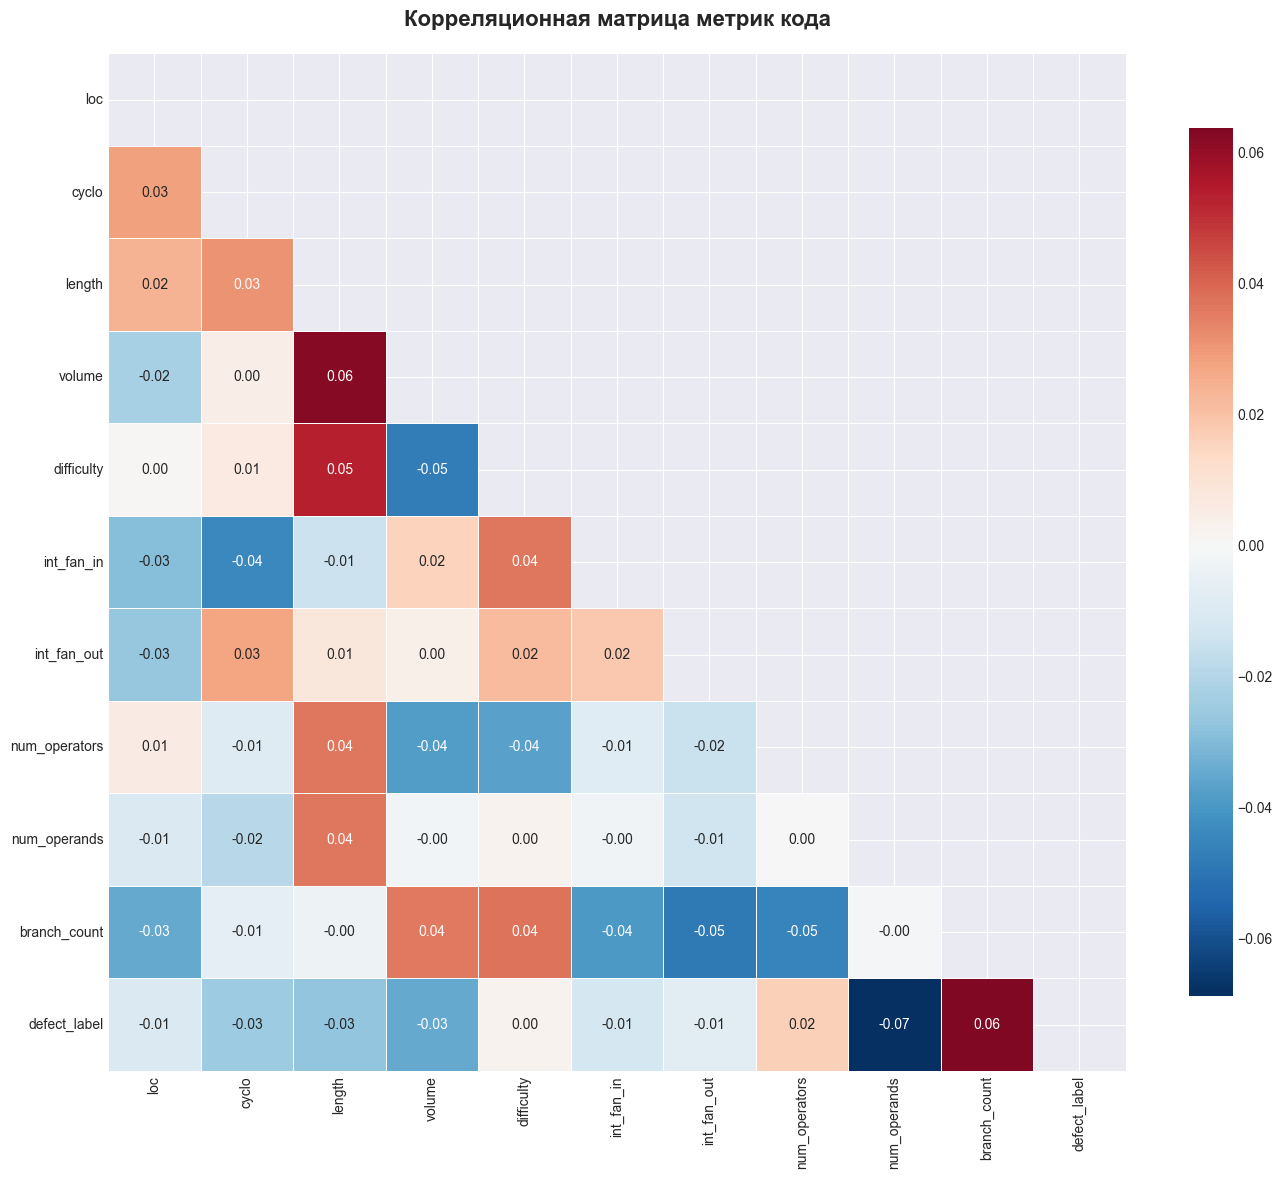

In [14]:
# Считаем корреляционную матрицу
corr_matrix = df[numeric_cols].corr()

# Тепловая карта
plt.figure(figsize=(14, 12))

# Маска для верхнего треугольника (чтобы не дублировать)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Корреляционная матрица метрик кода', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../images/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

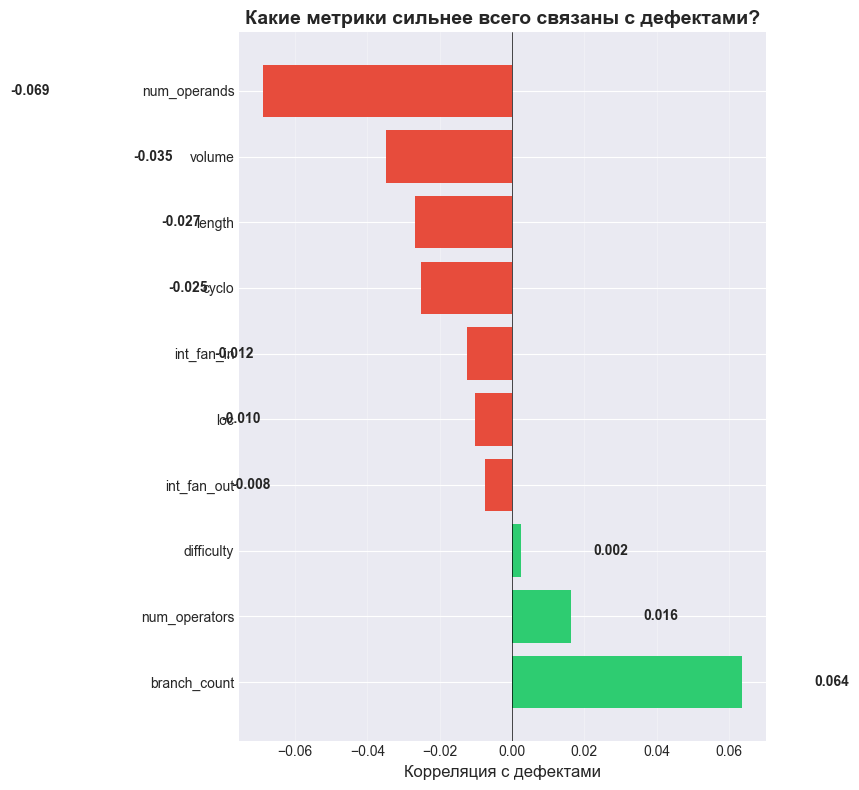


📊 Топ-5 метрик, наиболее связанных с дефектами:
  • branch_count: 0.064 (слабая положительная связь)
  • num_operators: 0.016 (слабая положительная связь)
  • difficulty: 0.002 (слабая положительная связь)
  • int_fan_out: -0.008 (слабая отрицательная связь)
  • loc: -0.010 (слабая отрицательная связь)


In [15]:
# Корреляция с целевой переменной
if target_col in corr_matrix.columns:
    target_corr = corr_matrix[target_col].drop(target_col).sort_values(ascending=False)
    
    plt.figure(figsize=(10, 8))
    
    # Цвета: зеленый для положительной, красный для отрицательной
    colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in target_corr.values]
    
    bars = plt.barh(range(len(target_corr)), target_corr.values, color=colors)
    plt.yticks(range(len(target_corr)), target_corr.index)
    plt.xlabel('Корреляция с дефектами', fontsize=12)
    plt.title('Какие метрики сильнее всего связаны с дефектами?', fontsize=14, fontweight='bold')
    
    # Добавляем значения
    for i, (bar, val) in enumerate(zip(bars, target_corr.values)):
        x_pos = val + 0.02 if val > 0 else val - 0.07
        plt.text(x_pos, i, f'{val:.3f}', va='center', fontweight='bold')
    
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('../images/target_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Топ-5 метрик, наиболее связанных с дефектами:")
    for metric, corr in target_corr.head(5).items():
        strength = "сильная" if abs(corr) > 0.5 else "умеренная" if abs(corr) > 0.3 else "слабая"
        direction = "положительная" if corr > 0 else "отрицательная"
        print(f"  • {metric}: {corr:.3f} ({strength} {direction} связь)")

## 📦 4. Сравнение дефектных и чистых модулей

C:\Users\Kuzmi\AppData\Local\Temp\ipykernel_9632\1663972668.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='class', y=plot_data, ax=axes[i],
C:\Users\Kuzmi\AppData\Local\Temp\ipykernel_9632\1663972668.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='class', y=plot_data, ax=axes[i],
C:\Users\Kuzmi\AppData\Local\Temp\ipykernel_9632\1663972668.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='class', y=plot_data, ax=axes[i],
C:\Users\Kuzmi\AppData\Local\Temp\ipykernel_9632\1663972668.py:24: 


branch_count:
               count  mean   std   min   25%   50%   75%   max
defect_label                                                  
0            674.000 0.501 0.319 0.000 0.214 0.500 0.786 1.000
1            326.000 0.543 0.303 0.000 0.286 0.571 0.786 1.000

num_operators:
               count  mean   std   min   25%   50%   75%   max
defect_label                                                  
0            674.000 0.491 0.298 0.000 0.232 0.475 0.758 1.000
1            326.000 0.501 0.290 0.002 0.231 0.525 0.748 1.000

difficulty:
               count  mean   std   min   25%   50%   75%   max
defect_label                                                  
0            674.000 0.502 0.284 0.000 0.271 0.513 0.747 1.000
1            326.000 0.503 0.287 0.003 0.254 0.501 0.760 0.992

int_fan_out:
               count  mean   std   min   25%   50%   75%   max
defect_label                                                  
0            674.000 0.512 0.322 0.000 0.222 0.556 0.778 1.0

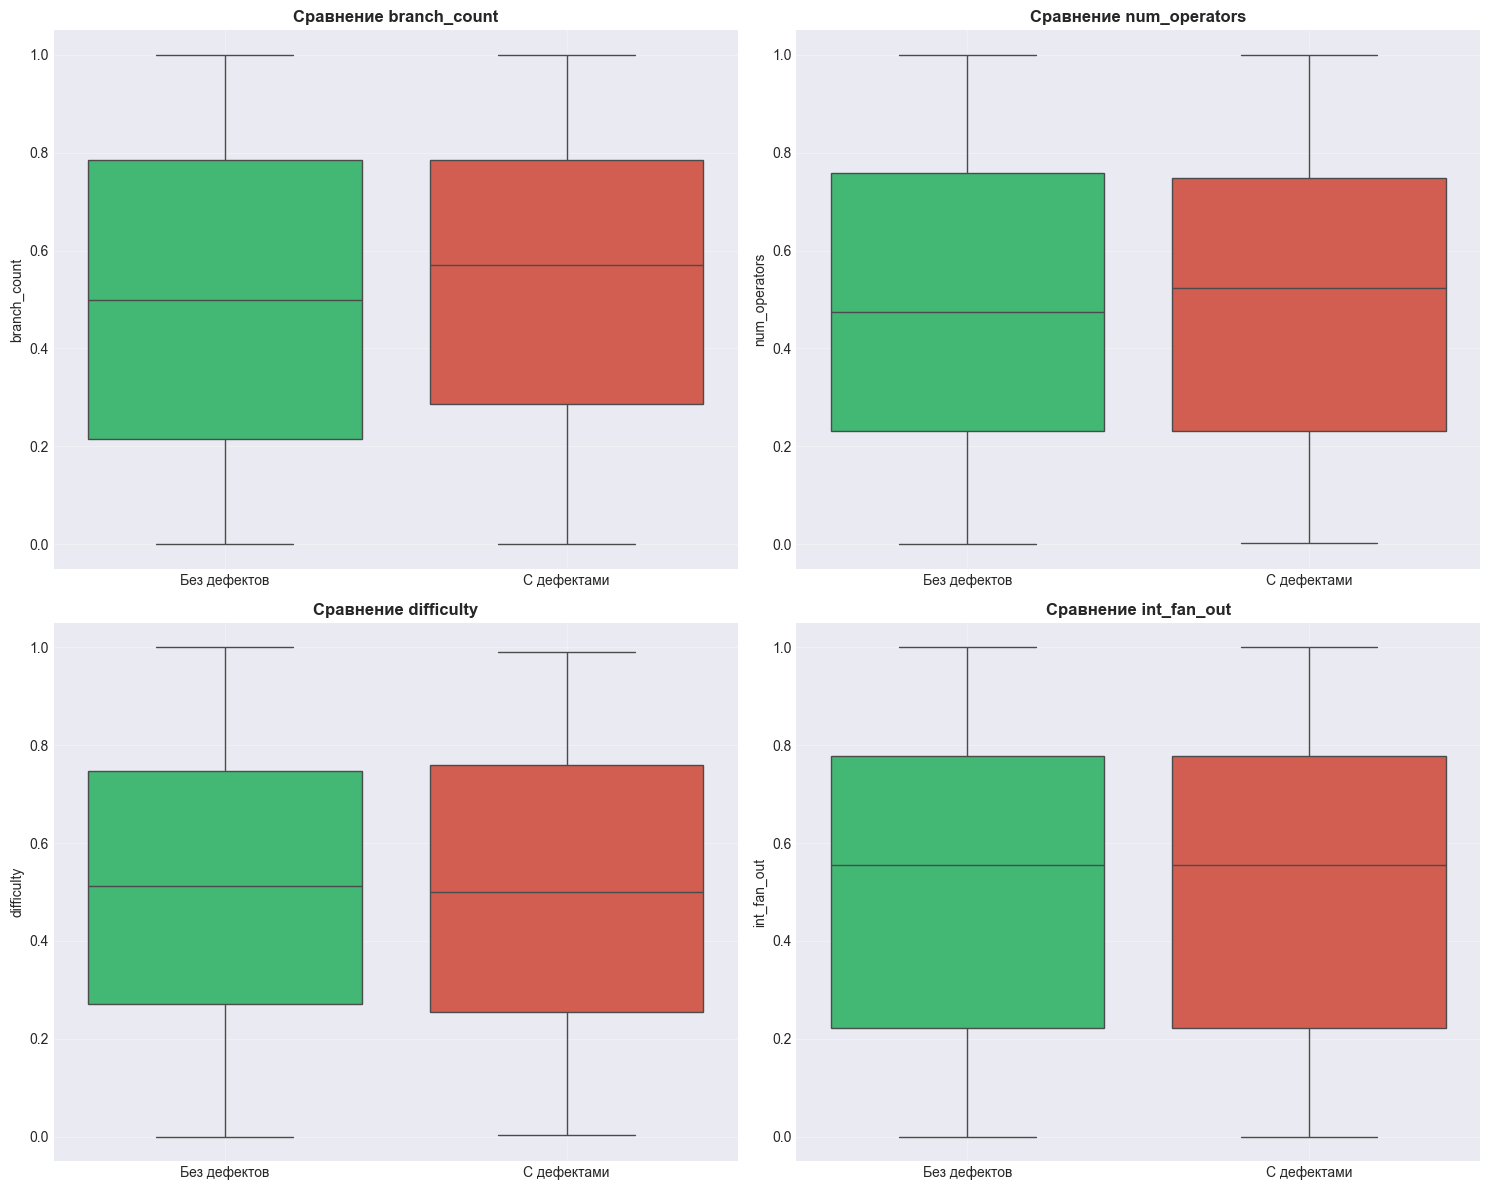

In [16]:
# Выбираем топ-4 метрики из корреляции
if target_col in corr_matrix.columns:
    top_metrics = target_corr.head(4).index.tolist()
else:
    top_metrics = available_metrics[:4]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, metric in enumerate(top_metrics):
    # Подготавливаем данные
    data = df[[metric, target_col]].copy()
    data['class'] = data[target_col].map({0: 'Без дефектов', 1: 'С дефектами'})
    
    # Логарифмическая шкала если нужно
    plot_data = data[metric].copy()
    if plot_data.max() > 1000:
        plot_data = np.log1p(plot_data)
        ylabel = f'log({metric}+1)'
    else:
        ylabel = metric
    
    # Boxplot
    sns.boxplot(data=data, x='class', y=plot_data, ax=axes[i], 
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(f'Сравнение {metric}', fontweight='bold')
    axes[i].set_ylabel(ylabel)
    axes[i].set_xlabel('')
    axes[i].grid(True, alpha=0.3)
    
    # Статистика
    stats = df.groupby(target_col)[metric].describe()
    print(f"\n{metric}:")
    print(stats)

plt.tight_layout()
plt.savefig('../images/comparison_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 5. Ключевые выводы

In [17]:
print("="*60)
print("📌 КЛЮЧЕВЫЕ ВЫВОДЫ ПО АНАЛИЗУ")
print("="*60)

# Вывод 1: Баланс классов
if len(class_counts) == 2:
    defect_pct = class_counts.get(1, 0) / len(df) * 100
    clean_pct = class_counts.get(0, 0) / len(df) * 100
    print(f"\n1️⃣ РАСПРЕДЕЛЕНИЕ ДЕФЕКТОВ:")
    print(f"   • Модулей с дефектами: {defect_pct:.1f}%")
    print(f"   • Модулей без дефектов: {clean_pct:.1f}%")
    if defect_pct < 20:
        print(f"   ⚠️  Сильный дисбаланс классов - нужно учитывать при обучении модели")

# Вывод 2: Самые важные признаки
if target_col in corr_matrix.columns:
    important = target_corr[abs(target_corr) > 0.2]
    print(f"\n2️⃣ НАИБОЛЕЕ ВАЖНЫЕ ПРИЗНАКИ:")
    print(f"   • Найдено {len(important)} признаков с |корреляцией| > 0.2")
    for metric, corr in important.head(3).items():
        effect = "увеличивает" if corr > 0 else "уменьшает"
        print(f"   • {metric}: {effect} вероятность дефектов (корр: {corr:.3f})")

# Вывод 3: Характеристики дефектных модулей
if target_col in df.columns:
    defect_df = df[df[target_col] == 1]
    clean_df = df[df[target_col] == 0]
    
    print(f"\n3️⃣ ХАРАКТЕРИСТИКИ ДЕФЕКТНЫХ МОДУЛЕЙ:")
    
    for metric in important_metrics[:3]:
        if metric in df.columns:
            defect_mean = defect_df[metric].mean()
            clean_mean = clean_df[metric].mean()
            ratio = defect_mean / clean_mean if clean_mean != 0 else 0
            print(f"   • {metric}: в {ratio:.1f} раз выше в дефектных модулях")
            print(f"     (дефектные: {defect_mean:.0f}, чистые: {clean_mean:.0f})")

print("\n" + "="*60)
print("🚀 РЕКОМЕНДАЦИИ")
print("="*60)
print("""
1. При разработке обращайте особое внимание на модули с высокими значениями:
   • loc (строк кода)
   • cyclo_complexity (цикломатическая сложность)
   • halstead_volume (объем)

2. Для построения модели предсказания дефектов:
   • Используйте методы балансировки классов (SMOTE, class_weight)
   • Рассмотрите отбор признаков для уменьшения размерности
   • Попробуйте градиентный бустинг (XGBoost, LightGBM)

3. Для тестирования:
   • Фокусируйте тесты на модулях с высокой сложностью
   • Проводите code review для модулей с LOC > 500
""")

📌 КЛЮЧЕВЫЕ ВЫВОДЫ ПО АНАЛИЗУ

1️⃣ РАСПРЕДЕЛЕНИЕ ДЕФЕКТОВ:
   • Модулей с дефектами: 32.6%
   • Модулей без дефектов: 67.4%

2️⃣ НАИБОЛЕЕ ВАЖНЫЕ ПРИЗНАКИ:
   • Найдено 0 признаков с |корреляцией| > 0.2

3️⃣ ХАРАКТЕРИСТИКИ ДЕФЕКТНЫХ МОДУЛЕЙ:
   • loc: в 1.0 раз выше в дефектных модулях
     (дефектные: 1, чистые: 1)

🚀 РЕКОМЕНДАЦИИ

1. При разработке обращайте особое внимание на модули с высокими значениями:
   • loc (строк кода)
   • cyclo_complexity (цикломатическая сложность)
   • halstead_volume (объем)

2. Для построения модели предсказания дефектов:
   • Используйте методы балансировки классов (SMOTE, class_weight)
   • Рассмотрите отбор признаков для уменьшения размерности
   • Попробуйте градиентный бустинг (XGBoost, LightGBM)

3. Для тестирования:
   • Фокусируйте тесты на модулях с высокой сложностью
   • Проводите code review для модулей с LOC > 500

